# Chapter 8: Trajectory Reconstruction and Anomaly Detection

This notebook demonstrates how an LSTM autoencoder can be used for AIS trajectory reconstruction and anomaly detection. The workflow is organized as follows:

1. Load and normalize AIS trajectory sequences.
2. Train an LSTM autoencoder to reconstruct normal vessel trajectories.
3. Measure reconstruction errors using ADE and DTW.
4. Build a reference DTW distribution from validation trajectories.
5. Detect abnormal trajectories in the test set.
6. Visualize reconstructed and anomalous trajectories on a map.

The code logic is kept unchanged. Only teaching explanations and comments are added, and repeated imports are removed.


## 1. Data preparation and baseline LSTM autoencoder training

This section loads the AIS training trajectories, normalizes the trajectory variables, defines an LSTM autoencoder, and trains the model using reconstruction loss. The autoencoder learns the normal trajectory pattern by reconstructing the input sequence.


In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import os
os.makedirs('lstm_ae_results', exist_ok=True)

# ── Data preparation ─────────────────────────────────────────────────────────
# Load AIS training data and organize each trajectory as a fixed-length sequence.
df = pd.read_csv('AIS_train.csv')
FEATURES = ['Lat', 'Lng', 'SOG', 'COG']
SEQ_LEN, INPUT_DIM = 110, 4

trajs = np.stack([g[FEATURES].values for _, g in df.groupby('traj_id')]).astype(np.float32)
mean, std = trajs.mean((0, 1)), trajs.std((0, 1))
trajs_norm = (trajs - mean) / std

class TrajDataset(Dataset):
    def __getitem__(self, i): return torch.tensor(trajs_norm[i])
    def __len__(self): return len(trajs_norm)

dataset = TrajDataset()
n_val = int(len(dataset) * 0.2)
train_set, val_set = random_split(dataset, [len(dataset) - n_val, n_val],
                                  generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32)

# ── LSTM autoencoder model ───────────────────────────────────────────────────
# The encoder compresses each trajectory into a latent vector, and the decoder reconstructs the whole sequence.
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.encoder     = nn.LSTM(input_dim,   hidden_dim, batch_first=True)
        self.h2z         = nn.Linear(hidden_dim, latent_dim)
        self.z2h         = nn.Linear(latent_dim, hidden_dim)
        self.decoder     = nn.LSTM(hidden_dim,   hidden_dim, batch_first=True)
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z    = self.h2z(h[-1])
        h_d  = self.z2h(z).unsqueeze(0)
        c_d  = torch.zeros_like(h_d)
        inp  = h_d.permute(1, 0, 2).expand(-1, x.size(1), -1).contiguous()
        out, _ = self.decoder(inp, (h_d, c_d))
        return self.output_proj(out)

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = LSTMAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ── Reconstruction metrics ───────────────────────────────────────────────────
# ADE measures average point-wise reconstruction error, while DTW measures sequence-level similarity.
def ade(pred, target):
    return np.mean(np.sqrt(((pred - target) ** 2).sum(-1)))

def batch_dtw(pred, target):
    return np.mean([fastdtw(p, t, dist=euclidean)[0] for p, t in zip(pred, target)])

# ── Model training ────────────────────────────────────────────────────────────
# The model is trained to minimize the reconstruction loss between input and output trajectories.
records = []
for epoch in range(1, 501):
    model.train()
    train_loss = 0
    for x in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(x)
    train_loss /= len(train_set)

    model.eval()
    val_loss, val_preds, val_targets = 0, [], []
    with torch.no_grad():
        for x in val_loader:
            xd  = x.to(device)
            out = model(xd)
            val_loss += criterion(out, xd).item() * len(x)
            val_preds.append(out.cpu().numpy())
            val_targets.append(x.numpy())
    val_loss /= len(val_set)
    vp, vt   = np.concatenate(val_preds), np.concatenate(val_targets)
    val_ade  = ade(vp, vt)
    val_dtw  = batch_dtw(vp[:20], vt[:20])

    records.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'val_ADE': val_ade, 'val_DTW': val_dtw})
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss {train_loss:.4f} | val_loss {val_loss:.4f} "
              f"| ADE {val_ade:.4f} | DTW {val_dtw:.2f}")

torch.save(model.state_dict(), 'lstm_ae_results/lstm_ae.pth')
pd.DataFrame(records).to_csv('lstm_ae_results/training_log.csv', index=False)
print("Done.")

Epoch  10 | loss 0.5692 | val_loss 0.5020 | ADE 1.0599 | DTW 112.30
Epoch  20 | loss 0.3946 | val_loss 0.3320 | ADE 0.7309 | DTW 76.47
Epoch  30 | loss 0.3338 | val_loss 0.2984 | ADE 0.6619 | DTW 67.18
Epoch  40 | loss 0.3005 | val_loss 0.2633 | ADE 0.5777 | DTW 62.79
Epoch  50 | loss 0.3078 | val_loss 0.2727 | ADE 0.6117 | DTW 61.95
Epoch  60 | loss 0.2763 | val_loss 0.2922 | ADE 0.6193 | DTW 61.96
Epoch  70 | loss 0.2941 | val_loss 0.2542 | ADE 0.5738 | DTW 59.99
Epoch  80 | loss 0.2650 | val_loss 0.2428 | ADE 0.5563 | DTW 58.41
Epoch  90 | loss 0.2528 | val_loss 0.2322 | ADE 0.5327 | DTW 55.10
Epoch 100 | loss 0.2658 | val_loss 0.2334 | ADE 0.5318 | DTW 57.27
Epoch 110 | loss 0.2876 | val_loss 0.2514 | ADE 0.5419 | DTW 58.37
Epoch 120 | loss 0.2382 | val_loss 0.2348 | ADE 0.5235 | DTW 54.10
Epoch 130 | loss 0.2312 | val_loss 0.2182 | ADE 0.4873 | DTW 52.62
Epoch 140 | loss 0.2586 | val_loss 0.2531 | ADE 0.5332 | DTW 55.75
Epoch 150 | loss 0.2225 | val_loss 0.2247 | ADE 0.5046 | DTW 

## 2. Training with geographic reconstruction metrics

This section repeats the autoencoder training procedure and evaluates reconstruction quality in geographic units. The haversine distance is used to compute trajectory errors in kilometers, which is more interpretable for maritime applications than errors in normalized coordinates.


In [1]:
os.makedirs('lstm_ae_results', exist_ok=True)

# ── Data preparation ─────────────────────────────────────────────────────────
# The same training data construction is repeated here, while the evaluation metrics are defined in geographic units.
df = pd.read_csv('AIS_train.csv')
FEATURES = ['Lat', 'Lng', 'SOG', 'COG']
SEQ_LEN, INPUT_DIM = 110, 4

trajs = np.stack([g[FEATURES].values for _, g in df.groupby('traj_id')]).astype(np.float32)
mean, std = trajs.mean((0, 1)), trajs.std((0, 1))
trajs_norm = (trajs - mean) / std

class TrajDataset(Dataset):
    def __getitem__(self, i): return torch.tensor(trajs_norm[i])
    def __len__(self): return len(trajs_norm)

dataset = TrajDataset()
n_val = int(len(dataset) * 0.2)
train_set, val_set = random_split(dataset, [len(dataset) - n_val, n_val],
                                  generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32)

# ── LSTM autoencoder model ───────────────────────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.encoder     = nn.LSTM(input_dim,   hidden_dim, batch_first=True)
        self.h2z         = nn.Linear(hidden_dim, latent_dim)
        self.z2h         = nn.Linear(latent_dim, hidden_dim)
        self.decoder     = nn.LSTM(hidden_dim,   hidden_dim, batch_first=True)
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z    = self.h2z(h[-1])
        h_d  = self.z2h(z).unsqueeze(0)
        c_d  = torch.zeros_like(h_d)
        inp  = h_d.permute(1, 0, 2).expand(-1, x.size(1), -1).contiguous()
        out, _ = self.decoder(inp, (h_d, c_d))
        return self.output_proj(out)

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = LSTMAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ── Geographic reconstruction metrics ───────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def ade(pred, target):
    # Denormalize to geographic coordinates and compute kilometer-level reconstruction error.
    pred_d   = pred * std + mean
    target_d = target * std + mean
    dist_km = haversine_km(pred_d[..., 0], pred_d[..., 1], target_d[..., 0], target_d[..., 1])
    return np.mean(dist_km)

def batch_dtw(pred, target):
    pred_d   = pred * std + mean
    target_d = target * std + mean

    def latlng_dist(p, t):
        return haversine_km(p[0], p[1], t[0], t[1])

    return np.mean([fastdtw(p[:, :2], t[:, :2], dist=latlng_dist)[0]
                     for p, t in zip(pred_d, target_d)])

# ── Model training ────────────────────────────────────────────────────────────
records = []
for epoch in range(1, 501):
    model.train()
    train_loss = 0
    for x in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(x)
    train_loss /= len(train_set)

    model.eval()
    val_loss, val_preds, val_targets = 0, [], []
    with torch.no_grad():
        for x in val_loader:
            xd  = x.to(device)
            out = model(xd)
            val_loss += criterion(out, xd).item() * len(x)
            val_preds.append(out.cpu().numpy())
            val_targets.append(x.numpy())
    val_loss /= len(val_set)
    vp, vt   = np.concatenate(val_preds), np.concatenate(val_targets)
    val_ade  = ade(vp, vt)
    val_dtw  = batch_dtw(vp[:20], vt[:20])

    records.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'val_ADE': val_ade, 'val_DTW': val_dtw})
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss {train_loss:.4f} | val_loss {val_loss:.4f} "
              f"| ADE {val_ade:.4f} | DTW {val_dtw:.2f}")

torch.save(model.state_dict(), 'lstm_ae_results/lstm_ae.pth')
pd.DataFrame(records).to_csv('lstm_ae_results/training_log.csv', index=False)
print("Done.")

Epoch  10 | loss 0.5903 | val_loss 0.5512 | ADE 49.7849 | DTW 4972.32
Epoch  20 | loss 0.3900 | val_loss 0.4106 | ADE 31.8354 | DTW 2233.16
Epoch  30 | loss 0.3546 | val_loss 0.3088 | ADE 21.6124 | DTW 1477.22
Epoch  40 | loss 0.3423 | val_loss 0.3057 | ADE 21.0335 | DTW 1566.39
Epoch  50 | loss 0.2940 | val_loss 0.2617 | ADE 16.4034 | DTW 1187.40
Epoch  60 | loss 0.2908 | val_loss 0.2570 | ADE 16.9020 | DTW 1127.36
Epoch  70 | loss 0.2825 | val_loss 0.2609 | ADE 15.6409 | DTW 1125.50
Epoch  80 | loss 0.2858 | val_loss 0.2685 | ADE 19.3861 | DTW 1758.29
Epoch  90 | loss 0.2789 | val_loss 0.2700 | ADE 16.9378 | DTW 1262.02
Epoch 100 | loss 0.2550 | val_loss 0.3121 | ADE 18.2329 | DTW 1133.60
Epoch 110 | loss 0.2282 | val_loss 0.2246 | ADE 13.8714 | DTW 1158.27
Epoch 120 | loss 0.2386 | val_loss 0.2716 | ADE 20.4439 | DTW 1255.84
Epoch 130 | loss 0.2371 | val_loss 0.2612 | ADE 15.6792 | DTW 1011.44
Epoch 140 | loss 0.2382 | val_loss 0.2245 | ADE 13.1590 | DTW 1011.77
Epoch 150 | loss 0.2

## 3. Visualizing trajectory reconstruction

After training, one validation trajectory is selected and reconstructed by the LSTM autoencoder. The ground-truth and reconstructed paths are plotted together to visually inspect the reconstruction quality.


/tmp/ipykernel_43576/3459343567.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('lstm_ae_results/lstm_ae.pth', map_location=device))


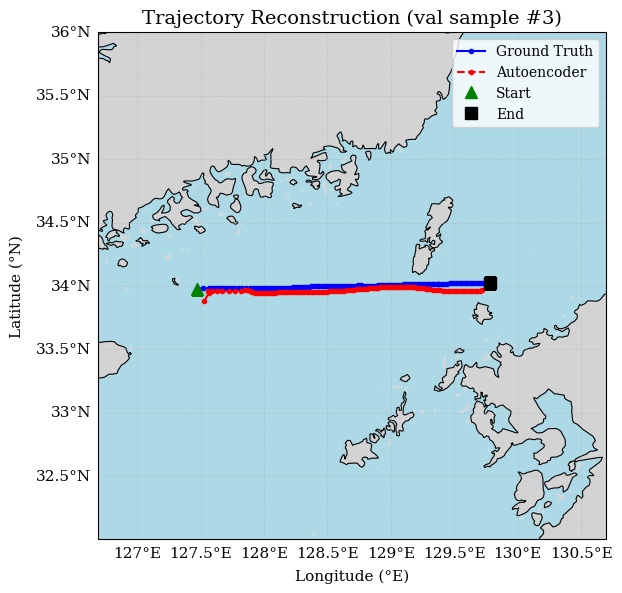

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# ── Font settings ─────────────────────────────────────────────────────────────
FONT_SIZE_TITLE  = 14
FONT_SIZE_LABEL  = 11
FONT_SIZE_LEGEND = 10
FONT_FAMILY      = 'serif'

# ── Reload trained model ─────────────────────────────────────────────────────
# The saved autoencoder is loaded for trajectory reconstruction visualization.
model = LSTMAutoencoder().to(device)
model.load_state_dict(torch.load('lstm_ae_results/lstm_ae.pth', map_location=device))
model.eval()

# ── Reconstruct validation samples ───────────────────────────────────────────
# Validation trajectories are reconstructed to check whether the model captures normal patterns.
val_indices = val_set.indices
val_real    = trajs_norm[val_indices]
val_real_t  = torch.tensor(val_real).to(device)

with torch.no_grad():
    val_pred = model(val_real_t).cpu().numpy()

# ── Select one validation sample ─────────────────────────────────────────────
idx  = 3
real = val_real[idx] * std + mean
pred = val_pred[idx] * std + mean

# ── Plot the real and reconstructed trajectory ───────────────────────────────
lat_c  = real[:, 0].mean();  lng_c = real[:, 1].mean()
extent = [lng_c - 2, lng_c + 2, lat_c - 2, lat_c + 2]

fig, ax = plt.subplots(figsize=(8, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      facecolor='lightgray')
ax.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Gridlines: left and bottom labels only
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': FONT_SIZE_LABEL, 'family': FONT_FAMILY}
gl.ylabel_style = {'size': FONT_SIZE_LABEL, 'family': FONT_FAMILY}

# Axis titles as text
ax.text(0.5, -0.08, 'Longitude (°E)', transform=ax.transAxes, ha='center',
        fontsize=FONT_SIZE_LABEL, fontfamily=FONT_FAMILY)
ax.text(-0.16, 0.5, 'Latitude (°N)',  transform=ax.transAxes, ha='center',
        va='center', rotation=90, fontsize=FONT_SIZE_LABEL, fontfamily=FONT_FAMILY)

ax.plot(real[:, 1], real[:, 0], 'b-o',  ms=3, lw=1.5, label='Ground Truth',
        transform=ccrs.PlateCarree())
ax.plot(pred[:, 1], pred[:, 0], 'r--o', ms=3, lw=1.5, label='Autoencoder',
        transform=ccrs.PlateCarree())
ax.plot(real[0, 1],  real[0, 0],  'g^', ms=8, label='Start',
        transform=ccrs.PlateCarree())
ax.plot(real[-1, 1], real[-1, 0], 'ks', ms=8, label='End',
        transform=ccrs.PlateCarree())

ax.set_title(f'Trajectory Reconstruction (val sample #{idx})',
             fontsize=FONT_SIZE_TITLE, fontfamily=FONT_FAMILY)
ax.legend(loc='best', fontsize=FONT_SIZE_LEGEND, prop={'family': FONT_FAMILY})

plt.tight_layout()
plt.savefig(f'lstm_ae_results/reconstruction_val_{idx}.png',
            dpi=900, bbox_inches='tight', pad_inches=0)
plt.show()

## 4. Constructing a DTW-based anomaly threshold

The reconstruction error of a normal trajectory is expected to be relatively small. This section computes Dynamic Time Warping (DTW) errors on validation trajectories and selects a percentile-based threshold. Trajectories with DTW values above this threshold can be treated as potential anomalies.


验证集DTW分布: min=241.622, max=5876.429, mean=948.053, median=898.026
90th 百分位阈值 = 1333.393 km


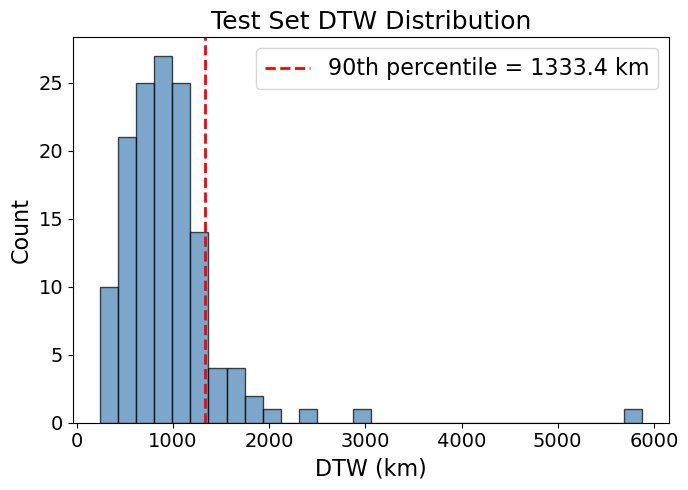

In [27]:
# ── Build a DTW reference distribution from normal validation trajectories ──
# The validation set is not used for parameter updates, so it is suitable for defining a normal-error reference.
val_indices = val_set.indices
val_real    = trajs_norm[val_indices]
val_real_t  = torch.tensor(val_real).to(device)

model.eval()
with torch.no_grad():
    val_pred_norm = model(val_real_t).cpu().numpy()

real = val_real * std + mean
pred = val_pred_norm * std + mean

ref_dtw = []
for i in range(len(real)):
    p, t = pred[i, :, :2], real[i, :, :2]
    d, _ = fastdtw(p, t, dist=lambda a, b: haversine_km(a[0], a[1], b[0], b[1]))
    ref_dtw.append(d)
ref_dtw = np.array(ref_dtw)

# ── Threshold setting based on a percentile of the reference distribution ───
PERCENTILE = 90
threshold = np.percentile(ref_dtw, PERCENTILE)

print(f"验证集DTW分布: min={ref_dtw.min():.3f}, max={ref_dtw.max():.3f}, "
      f"mean={ref_dtw.mean():.3f}, median={np.median(ref_dtw):.3f}")
print(f"{PERCENTILE}th 百分位阈值 = {threshold:.3f} km")

# ── Adjustable font sizes ───────────────────────────────────────────────────
FONT_SIZE_TITLE  = 18
FONT_SIZE_LABEL  = 16
FONT_SIZE_TICK   = 14
FONT_SIZE_LEGEND = 16

# ── Plot the DTW error distribution ─────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.hist(ref_dtw, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', lw=2,
            label=f'{PERCENTILE}th percentile = {threshold:.1f} km')
plt.xlabel('DTW (km)', fontsize=FONT_SIZE_LABEL)
plt.ylabel('Count', fontsize=FONT_SIZE_LABEL)
plt.title('Test Set DTW Distribution', fontsize=FONT_SIZE_TITLE)
plt.xticks(fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
plt.legend(fontsize=FONT_SIZE_LEGEND)
plt.tight_layout()
plt.savefig('lstm_ae_results/val_dtw_distribution.png', dpi=900)
plt.show()

## 5. Detecting anomalous trajectories in the test set

This section applies the trained autoencoder to the test trajectories. Each trajectory is reconstructed, its DTW reconstruction error is calculated, and trajectories exceeding the predefined threshold are identified as anomalies.


In [18]:
# ── Load test data ──────────────────────────────────────────────────────────
df_test = pd.read_csv('AIS_test.csv')
FEATURES = ['Lat', 'Lng', 'SOG', 'COG']

# Re-index traj_id while preserving the original trajectory order.
new_id_map = {old: new for new, old in enumerate(df_test['traj_id'].unique())}
df_test['traj_id'] = df_test['traj_id'].map(new_id_map)

# Stack trajectories into an array with shape (N, SEQ_LEN, 4).
test_trajs = np.stack([g[FEATURES].values for _, g in df_test.groupby('traj_id')]).astype(np.float32)
test_norm  = (test_trajs - mean) / std

# ── Reconstruct test trajectories using the autoencoder ────────────────────
model.eval()
with torch.no_grad():
    pred_norm = model(torch.tensor(test_norm).to(device)).cpu().numpy()

real = test_trajs                       # Ground-truth trajectories in original units
pred = pred_norm * std + mean            # Denormalized reconstructed trajectories

# ── Compute DTW for each trajectory using haversine distance in kilometers ──
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

dtw_list = []
for i in range(len(real)):
    p, t = pred[i, :, :2], real[i, :, :2]
    d, _ = fastdtw(p, t, dist=lambda a, b: haversine_km(a[0], a[1], b[0], b[1]))
    dtw_list.append(d)

# ── Summarize DTW values in a table ─────────────────────────────────────────
dtw_df = pd.DataFrame({'traj_id': np.arange(len(real)), 'DTW': dtw_list})


# ── Select anomalous trajectories above the DTW threshold ──────────────────
threshold = 1333.630  # 90th percentile threshold (km)

anomaly_df = dtw_df[dtw_df['DTW'] > threshold].sort_values('DTW', ascending=False)
anomaly_ids = anomaly_df['traj_id'].tolist()

print(f"异常轨迹数量: {len(anomaly_ids)} / {len(dtw_df)}")
anomaly_df

异常轨迹数量: 28 / 150


,traj_id,DTW
12,12,5235.392488
28,28,4233.832474
86,86,3435.760341
63,63,3043.223396
51,51,2017.474320
145,145,1973.958033
128,128,1961.855394
69,69,1839.029314
0,0,1818.264279
133,133,1731.914163


## 6. Visualizing a detected anomalous trajectory

The final section plots one detected anomalous trajectory and its autoencoder reconstruction. A large mismatch between the two curves indicates that the trajectory deviates from the learned normal trajectory pattern.


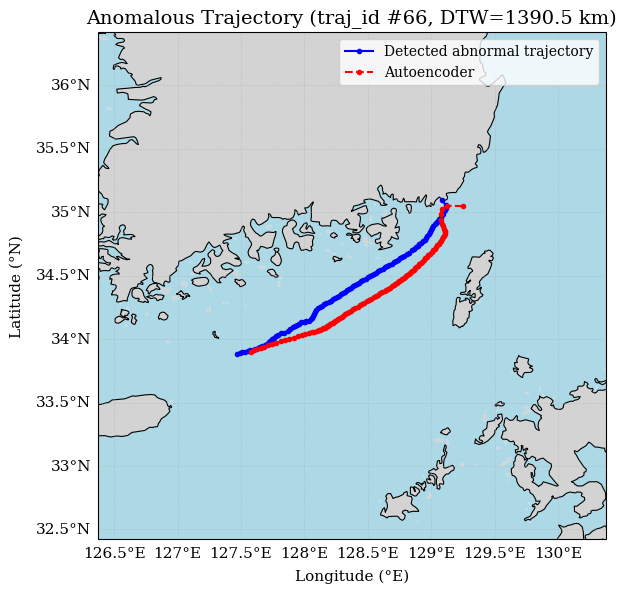

In [24]:
# ── Font settings ─────────────────────────────────────────────────────────────
FONT_SIZE_TITLE  = 14
FONT_SIZE_LABEL  = 11
FONT_SIZE_LEGEND = 10
FONT_FAMILY      = 'serif'

# ── Specify the anomalous trajectory ID to be plotted ──────────────────────
idx = 66  # Specify the target traj_id here.

real_traj = real[idx]
pred_traj = pred[idx]

lat_c  = real_traj[:, 0].mean();  lng_c = real_traj[:, 1].mean()
extent = [lng_c - 2, lng_c + 2, lat_c - 2, lat_c + 2]

fig, ax = plt.subplots(figsize=(8, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      facecolor='lightgray')
ax.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': FONT_SIZE_LABEL, 'family': FONT_FAMILY}
gl.ylabel_style = {'size': FONT_SIZE_LABEL, 'family': FONT_FAMILY}

ax.text(0.5, -0.08, 'Longitude (°E)', transform=ax.transAxes, ha='center',
        fontsize=FONT_SIZE_LABEL, fontfamily=FONT_FAMILY)
ax.text(-0.16, 0.5, 'Latitude (°N)',  transform=ax.transAxes, ha='center',
        va='center', rotation=90, fontsize=FONT_SIZE_LABEL, fontfamily=FONT_FAMILY)

ax.plot(real_traj[:, 1], real_traj[:, 0], 'b-o',  ms=3, lw=1.5, label='Detected abnormal trajectory',
        transform=ccrs.PlateCarree())
ax.plot(pred_traj[:, 1], pred_traj[:, 0], 'r--o', ms=3, lw=1.5, label='Autoencoder',
        transform=ccrs.PlateCarree())

dtw_val = dtw_df.loc[dtw_df['traj_id'] == idx, 'DTW'].values[0]
ax.set_title(f'Anomalous Trajectory (traj_id #{idx}, DTW={dtw_val:.1f} km)',
             fontsize=FONT_SIZE_TITLE, fontfamily=FONT_FAMILY)
ax.legend(loc='best', fontsize=FONT_SIZE_LEGEND, prop={'family': FONT_FAMILY})

plt.tight_layout()
plt.savefig(f'lstm_ae_results/anomaly_traj_{idx}.png',
            dpi=900, bbox_inches='tight', pad_inches=0)
plt.show()